In [2]:
# ============================================================

# ============================================================
 
# ─────────────────────────────────────────────
# CELL 1: Import Libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
 
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
 
print("✅ All libraries imported successfully!")
 

✅ All libraries imported successfully!


In [3]:
# CELL 2: Load Dataset
# ─────────────────────────────────────────────
# Load actual dataset from data folder

df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\Data-Science-Month-5\data\airline_delay.csv")

if 'FlightDate' in df.columns:
    df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors='coerce')
    print("ℹ️ Converted 'FlightDate' to datetime")

print(f"✅ Dataset loaded | Shape: {df.shape}")
print(f"\n📊 First few rows:\n{df.head()}")
print(f"\n📊 Class Distribution (if Delayed column exists):\n{df.columns.tolist()}")

✅ Dataset loaded | Shape: (3351, 21)

📊 First few rows:
   year  month carrier       carrier_name airport  \
0  2020     12      9E  Endeavor Air Inc.     ABE   
1  2020     12      9E  Endeavor Air Inc.     ABY   
2  2020     12      9E  Endeavor Air Inc.     AEX   
3  2020     12      9E  Endeavor Air Inc.     AGS   
4  2020     12      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         44.0        3.0   
1             Albany, GA: Southwest Georgia Regional         90.0        1.0   
2           Alexandria, LA: Alexandria International         88.0        8.0   
3        Augusta, GA: Augusta Regional at Bush Field        184.0        9.0   
4                   Albany, NY: Albany International         76.0       11.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        1.63         0.0  ...          0.0              1.25   


📋 DATASET OVERVIEW
   year  month carrier       carrier_name airport  \
0  2020     12      9E  Endeavor Air Inc.     ABE   
1  2020     12      9E  Endeavor Air Inc.     ABY   
2  2020     12      9E  Endeavor Air Inc.     AEX   
3  2020     12      9E  Endeavor Air Inc.     AGS   
4  2020     12      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         44.0        3.0   
1             Albany, GA: Southwest Georgia Regional         90.0        1.0   
2           Alexandria, LA: Alexandria International         88.0        8.0   
3        Augusta, GA: Augusta Regional at Bush Field        184.0        9.0   
4                   Albany, NY: Albany International         76.0       11.0   

   carrier_ct  weather_ct  ...  arr_cancelled  arr_diverted  arr_delay  \
0        1.63         0.0  ...            0.0           1.0       89.0   
1        0.96         0.0  ...  

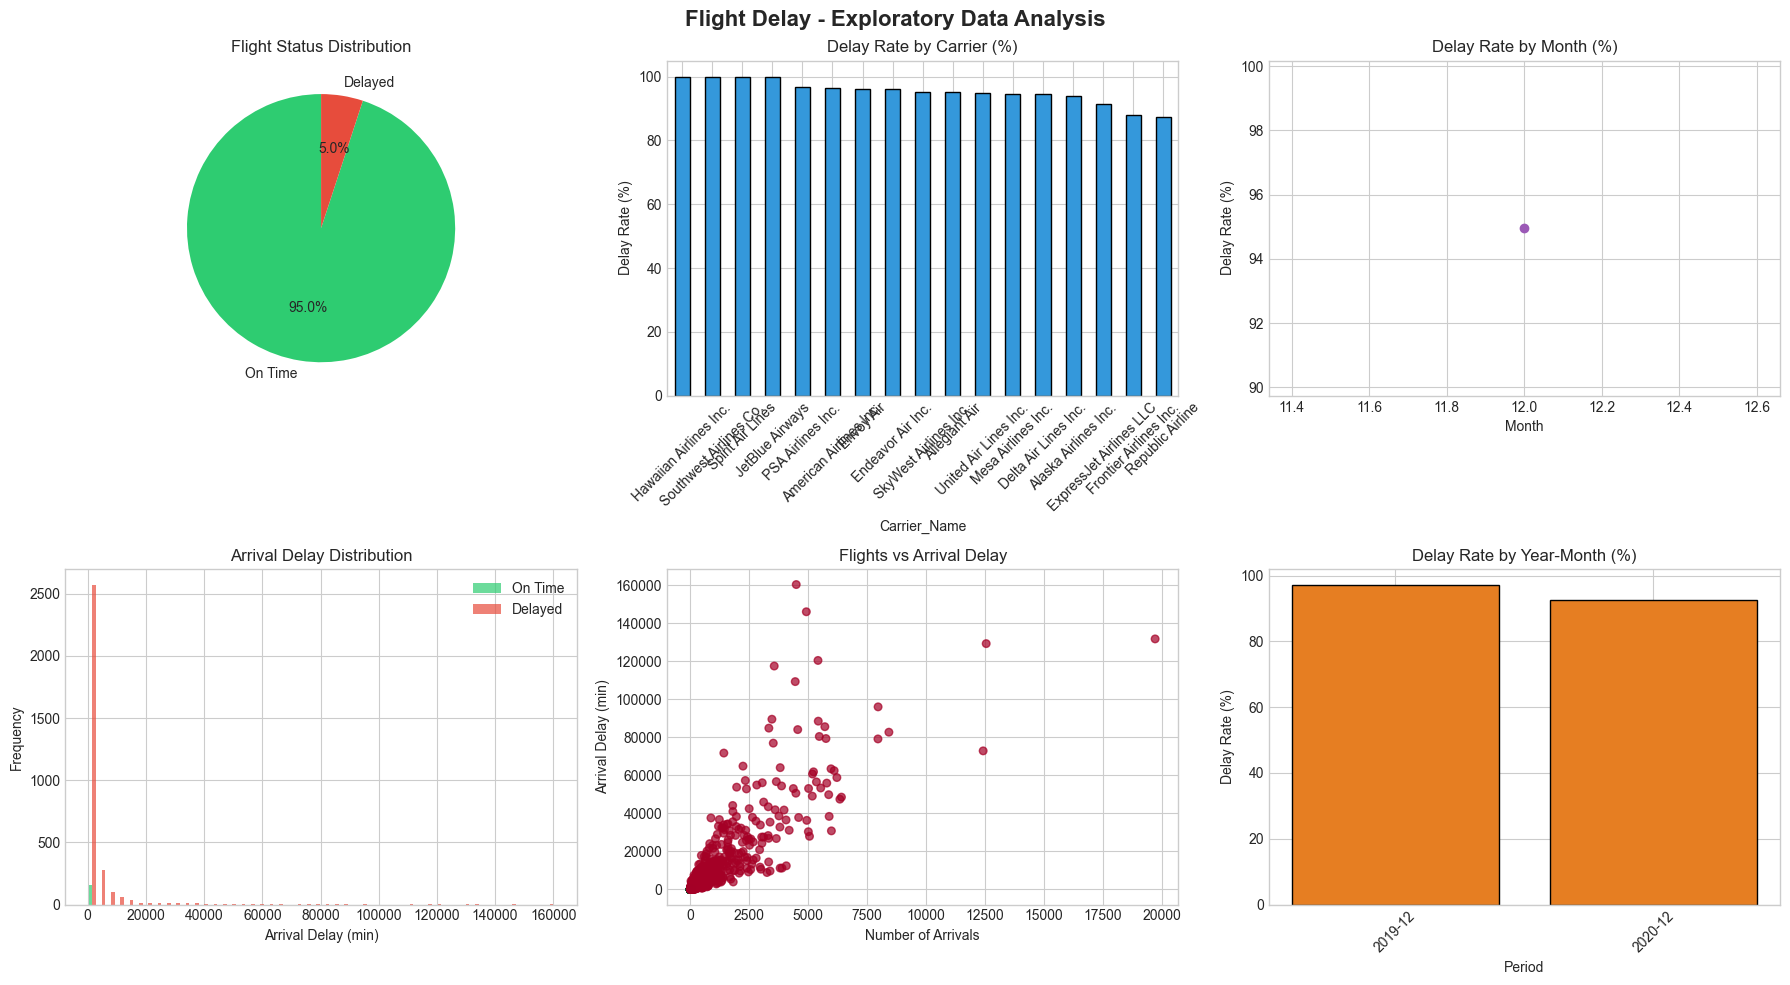

✅ EDA plots saved as 'eda_plots.png'


In [15]:
# CELL 3: Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("📋 DATASET OVERVIEW")
print("="*50)
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Stats:\n{df.describe()}")
 
# ─── EDA Plots ───
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Flight Delay - Exploratory Data Analysis', fontsize=16, fontweight='bold')
 
# 1. Class Distribution
if 'Delayed' not in df.columns:
    if 'arr_del15' in df.columns:
        df['Delayed'] = (df['arr_del15'] > 0).astype(int)
        print("ℹ️ Created 'Delayed' from 'arr_del15'")
    else:
        raise KeyError("Dataset must contain 'Delayed' or 'arr_del15'")

if 'Month' not in df.columns and 'month' in df.columns:
    df['Month'] = df['month']

axes[0, 0].pie(
    df['Delayed'].value_counts(),
    labels=['On Time', 'Delayed'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0, 0].set_title('Flight Status Distribution')
 
# 2. Delay by Carrier
carrier_col = 'carrier_name' if 'carrier_name' in df.columns else 'carrier'
if carrier_col in df.columns:
    delay_by_airline = df.groupby(carrier_col)['Delayed'].mean() * 100
    delay_by_airline.sort_values(ascending=False).plot(
        kind='bar', ax=axes[0, 1], color='#3498db', edgecolor='black'
    )
    axes[0, 1].set_title('Delay Rate by Carrier (%)')
    axes[0, 1].set_xlabel(carrier_col.title())
    axes[0, 1].set_ylabel('Delay Rate (%)')
    axes[0, 1].tick_params(axis='x', rotation=45)
else:
    axes[0, 1].text(0.5, 0.5, 'Carrier column not found', ha='center', va='center')
    axes[0, 1].set_title('Delay Rate by Carrier (%)')
 
# 3. Delay by Month
if 'Month' in df.columns:
    delay_by_month = df.groupby('Month')['Delayed'].mean() * 100
    delay_by_month.plot(kind='line', ax=axes[0, 2], marker='o', color='#9b59b6', linewidth=2)
    axes[0, 2].set_title('Delay Rate by Month (%)')
    axes[0, 2].set_xlabel('Month')
    axes[0, 2].set_ylabel('Delay Rate (%)')
elif 'FlightDate' in df.columns:
    try:
        df_month = df.copy()
        df_month['Month'] = pd.to_datetime(df_month['FlightDate']).dt.month
        delay_by_month = df_month.groupby('Month')['Delayed'].mean() * 100
        delay_by_month.plot(kind='line', ax=axes[0, 2], marker='o', color='#9b59b6', linewidth=2)
        axes[0, 2].set_title('Delay Rate by Month (%)')
        axes[0, 2].set_xlabel('Month')
        axes[0, 2].set_ylabel('Delay Rate (%)')
    except:
        axes[0, 2].text(0.5, 0.5, 'Month data not available', ha='center', va='center')
        axes[0, 2].set_title('Delay Rate by Month (%)')
else:
    axes[0, 2].text(0.5, 0.5, 'Month data not available', ha='center', va='center')
    axes[0, 2].set_title('Delay Rate by Month (%)')
# 4. Arrival Delay Distribution
if 'arr_delay' in df.columns:
    axes[1, 0].hist(
        [df[df['Delayed']==0]['arr_delay'].dropna(), df[df['Delayed']==1]['arr_delay'].dropna()],
        bins=50, label=['On Time', 'Delayed'],
        color=['#2ecc71', '#e74c3c'], alpha=0.7
    )
    axes[1, 0].set_title('Arrival Delay Distribution')
    axes[1, 0].set_xlabel('Arrival Delay (min)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, 'arr_delay column not found', ha='center', va='center')
    axes[1, 0].set_title('Arrival Delay Distribution')
 
# 5. Flights vs Arrival Delay
if 'arr_flights' in df.columns and 'arr_delay' in df.columns:
    axes[1, 1].scatter(
        df['arr_flights'], df['arr_delay'],
        c=df['Delayed'], cmap='RdYlGn_r',
        alpha=0.7, s=30
    )
    axes[1, 1].set_title('Flights vs Arrival Delay')
    axes[1, 1].set_xlabel('Number of Arrivals')
    axes[1, 1].set_ylabel('Arrival Delay (min)')
else:
    axes[1, 1].text(0.5, 0.5, 'arr_flights/arr_delay columns not found', ha='center', va='center')
    axes[1, 1].set_title('Flights vs Arrival Delay')
# 6. Delay Rate by Year-Month
if 'year' in df.columns and 'month' in df.columns:
    try:
        df_temp = df.copy()
        df_temp['YearMonth'] = df_temp['year'].astype(str) + '-' + df_temp['month'].astype(int).astype(str).str.zfill(2)
        delay_by_period = df_temp.groupby('YearMonth')['Delayed'].mean() * 100
        axes[1, 2].bar(delay_by_period.index, delay_by_period.values, color='#e67e22', edgecolor='black')
        axes[1, 2].set_title('Delay Rate by Year-Month (%)')
        axes[1, 2].set_xlabel('Period')
        axes[1, 2].set_ylabel('Delay Rate (%)')
        axes[1, 2].tick_params(axis='x', rotation=45)
    except Exception:
        axes[1, 2].text(0.5, 0.5, 'Year-Month data not available', ha='center', va='center')
        axes[1, 2].set_title('Delay Rate by Year-Month (%)')
else:
    axes[1, 2].text(0.5, 0.5, 'Year/Month columns not found', ha='center', va='center')
    axes[1, 2].set_title('Delay Rate by Year-Month (%)')
 
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved as 'eda_plots.png'")

In [8]:
# CELL 4: Data Preprocessing
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("🔧 DATA PREPROCESSING")
print("="*50)
 
df_clean = df.copy()
 
# Step 1: Prepare target and date features
if 'Delayed' not in df_clean.columns:
    if 'arr_del15' in df_clean.columns:
        df_clean['Delayed'] = (df_clean['arr_del15'] > 0).astype(int)
        print("ℹ️ Created 'Delayed' from 'arr_del15'")
    else:
        raise KeyError("Dataset must contain 'Delayed' or 'arr_del15'.")

if 'FlightDate' in df_clean.columns:
    df_clean['FlightDate'] = pd.to_datetime(df_clean['FlightDate'], errors='coerce')
    df_clean['Month']   = df_clean['FlightDate'].dt.month
    df_clean['Year']    = df_clean['FlightDate'].dt.year
    print("✅ Date features extracted: Month, Year")
elif 'month' in df_clean.columns:
    df_clean['Month'] = df_clean['month']
    if 'year' in df_clean.columns:
        df_clean['Year'] = df_clean['year']
    print("ℹ️ Using existing month/year fields")
else:
    raise KeyError("Dataset must contain 'FlightDate' or 'month' and 'year' columns.")
 
# Step 2: Drop columns with too many missing values
missing_threshold = 0.5  # Drop if >50% missing
missing_pct = df_clean.isnull().mean()
cols_to_drop = missing_pct[missing_pct > missing_threshold].index.tolist()
 
# Also drop original date and target-leaking columns
cols_to_drop += ['FlightDate', 'ArrDelay', 'DepDelay', 'arr_del15', 'arr_delay', 'carrier_name', 'airport_name']
cols_to_drop = list(set(cols_to_drop))
 
df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], inplace=True)
print(f"✅ Dropped columns: {cols_to_drop}")
 
# Step 3: Drop remaining rows with missing values
before = len(df_clean)
df_clean.dropna(inplace=True)
after = len(df_clean)
print(f"✅ Dropped {before - after} rows with missing values | Remaining: {after}")
 
# Step 4: Label Encode categorical columns
le = LabelEncoder()
cat_cols = ['carrier', 'airport']
 
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        print(f"   ✅ Label Encoded: {col}")
 
print(f"\n📋 Final Feature Columns:\n{list(df_clean.columns)}")
print(f"\n📊 Final Shape: {df_clean.shape}")
 
# ─────────────────────────────────────────────
# CELL 5: Feature Selection & Train/Test Split
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("✂️  TRAIN / TEST SPLIT")
print("="*50)
 
# Separate features (X) and target (y)
X = df_clean.drop('Delayed', axis=1)
y = df_clean['Delayed']
 
print(f"Features (X) shape : {X.shape}")
print(f"Target  (y) shape  : {y.shape}")
print(f"Feature names      : {list(X.columns)}")

# 80% train, 20% test | stratify ensures balanced class split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train set: {X_train.shape} | Test set: {X_test.shape}")
print(f"   Train delay rate: {y_train.mean()*100:.1f}% | Test delay rate: {y_test.mean()*100:.1f}%")


🔧 DATA PREPROCESSING
ℹ️ Using existing month/year fields
✅ Dropped columns: ['ArrDelay', 'carrier_name', 'arr_del15', 'FlightDate', 'airport_name', 'DepDelay', 'arr_delay']
✅ Dropped 8 rows with missing values | Remaining: 3343
   ✅ Label Encoded: carrier
   ✅ Label Encoded: airport

📋 Final Feature Columns:
['year', 'month', 'carrier', 'airport', 'arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'Delayed', 'Month', 'Year']

📊 Final Shape: (3343, 20)

✂️  TRAIN / TEST SPLIT
Features (X) shape : (3343, 19)
Target  (y) shape  : (3343,)
Feature names      : ['year', 'month', 'carrier', 'airport', 'arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'Month', 'Year']

✅ Train set:

In [9]:
# CELL 6: Model 1 - Logistic Regression
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("🤖 MODEL 1: LOGISTIC REGRESSION")
print("="*50)
 
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)
 
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
 
lr_acc  = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec  = recall_score(y_test, y_pred_lr)
lr_f1   = f1_score(y_test, y_pred_lr)
 
print(f"   Accuracy  : {lr_acc*100:.2f}%")
print(f"   Precision : {lr_prec*100:.2f}%")
print(f"   Recall    : {lr_rec*100:.2f}%")
print(f"   F1 Score  : {lr_f1*100:.2f}%")
 
print(f"\n📋 Classification Report:\n{classification_report(y_test, y_pred_lr, target_names=['On Time', 'Delayed'])}")
 


🤖 MODEL 1: LOGISTIC REGRESSION
   Accuracy  : 99.85%
   Precision : 100.00%
   Recall    : 99.84%
   F1 Score  : 99.92%

📋 Classification Report:
              precision    recall  f1-score   support

     On Time       0.97      1.00      0.98        32
     Delayed       1.00      1.00      1.00       637

    accuracy                           1.00       669
   macro avg       0.98      1.00      0.99       669
weighted avg       1.00      1.00      1.00       669



In [10]:
# CELL 7: Model 2 - Random Forest
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("🌲 MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*50)
 
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
 
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
 
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf)
rf_f1   = f1_score(y_test, y_pred_rf)
 
print(f"   Accuracy  : {rf_acc*100:.2f}%")
print(f"   Precision : {rf_prec*100:.2f}%")
print(f"   Recall    : {rf_rec*100:.2f}%")
print(f"   F1 Score  : {rf_f1*100:.2f}%")
 
print(f"\n📋 Classification Report:\n{classification_report(y_test, y_pred_rf, target_names=['On Time', 'Delayed'])}")
 


🌲 MODEL 2: RANDOM FOREST CLASSIFIER
   Accuracy  : 99.85%
   Precision : 100.00%
   Recall    : 99.84%
   F1 Score  : 99.92%

📋 Classification Report:
              precision    recall  f1-score   support

     On Time       0.97      1.00      0.98        32
     Delayed       1.00      1.00      1.00       637

    accuracy                           1.00       669
   macro avg       0.98      1.00      0.99       669
weighted avg       1.00      1.00      1.00       669




📊 MODEL EVALUATION VISUALIZATIONS


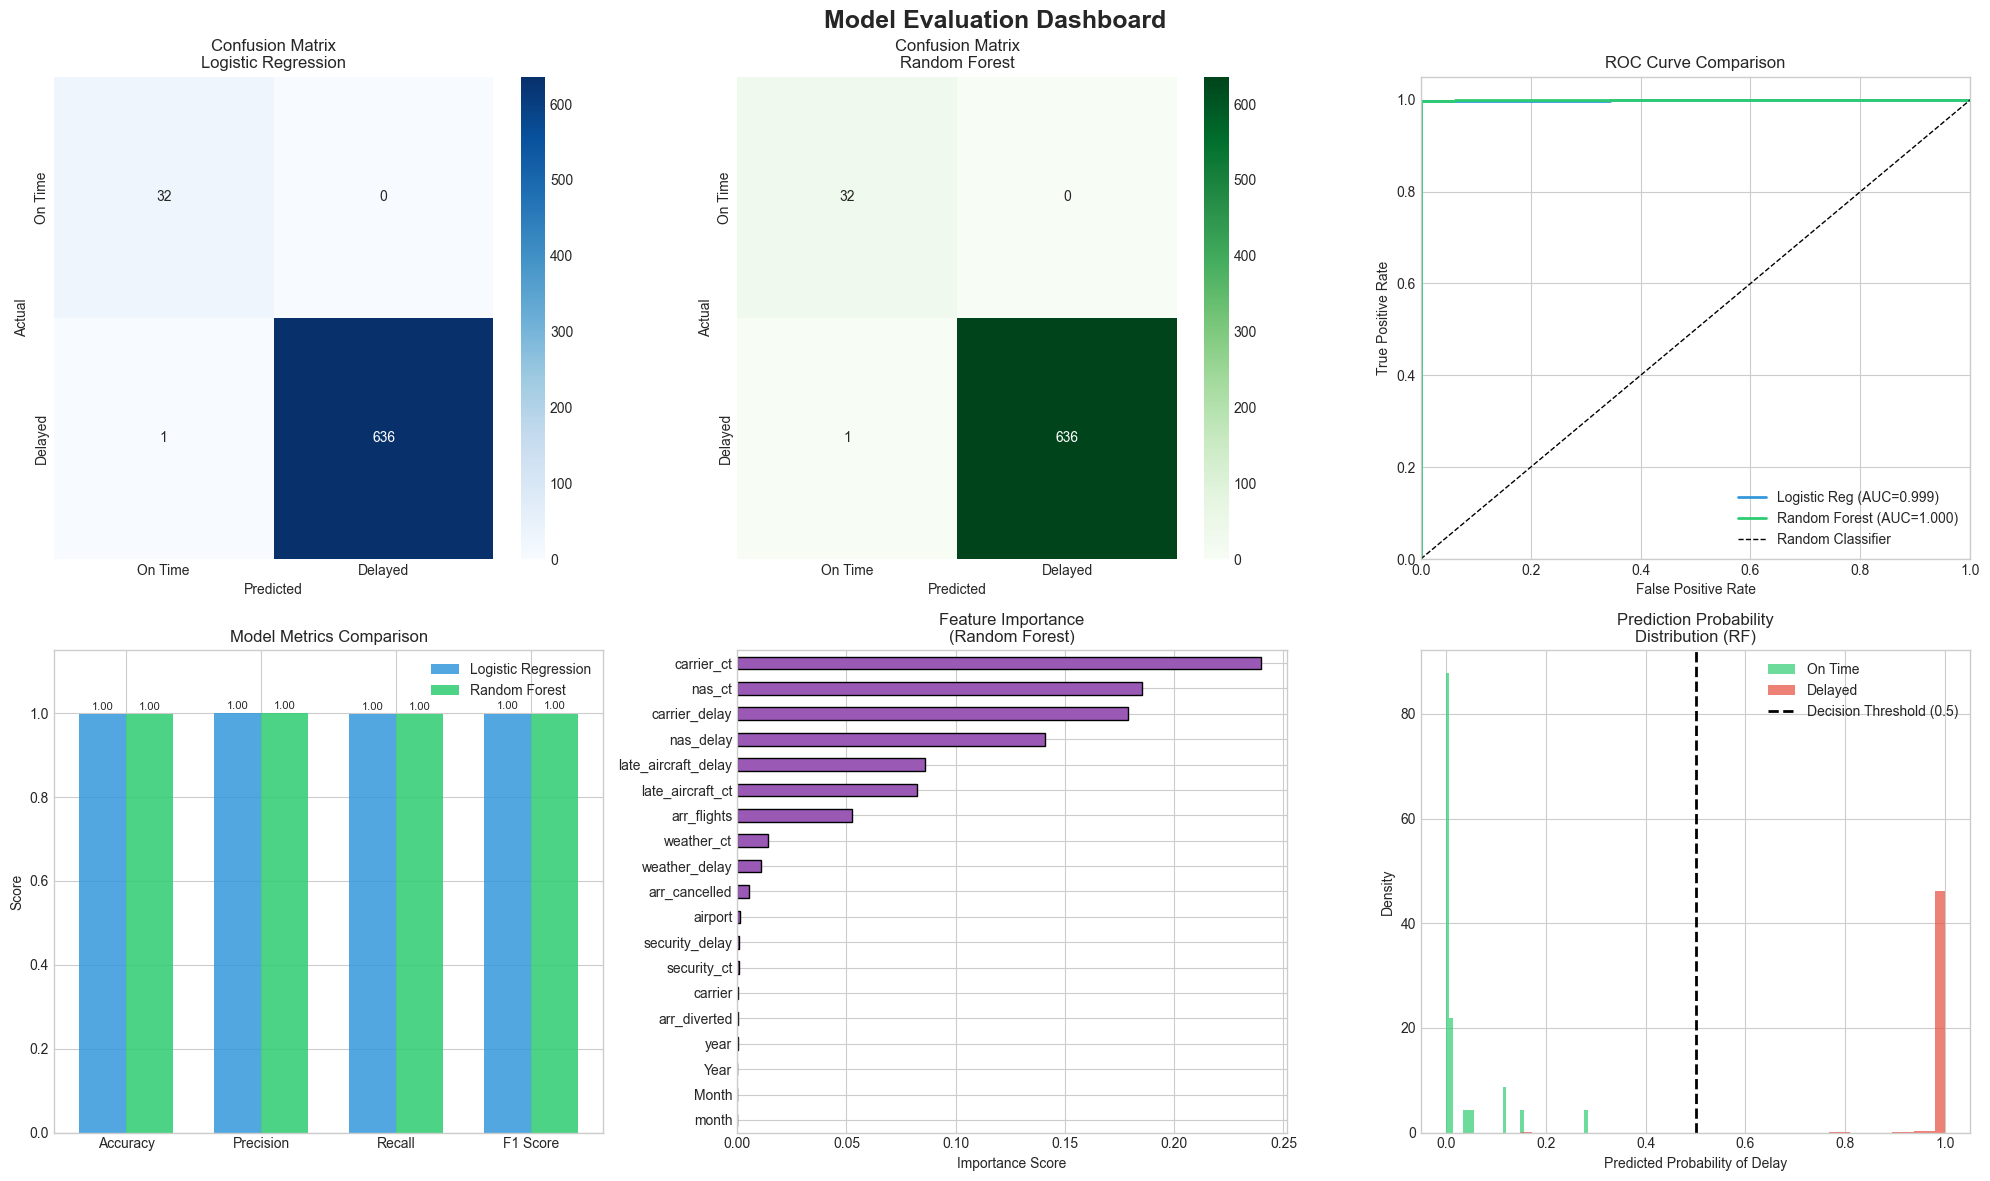

✅ Evaluation plots saved as 'model_evaluation.png'


In [11]:
# CELL 8: Model Evaluation Plots
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("📊 MODEL EVALUATION VISUALIZATIONS")
print("="*50)
 
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Evaluation Dashboard', fontsize=18, fontweight='bold')
 
# ── 1. Confusion Matrix - Logistic Regression ──
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'], ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix\nLogistic Regression', fontsize=12)
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')
 
# ── 2. Confusion Matrix - Random Forest ──
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'], ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix\nRandom Forest', fontsize=12)
axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_xlabel('Predicted')
 
# ── 3. ROC Curve - Both Models ──
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
 
axes[0, 2].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={auc_lr:.3f})', color='#3498db', lw=2)
axes[0, 2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', color='#2ecc71', lw=2)
axes[0, 2].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0, 2].set_title('ROC Curve Comparison', fontsize=12)
axes[0, 2].set_xlabel('False Positive Rate')
axes[0, 2].set_ylabel('True Positive Rate')
axes[0, 2].legend()
axes[0, 2].set_xlim([0, 1])
axes[0, 2].set_ylim([0, 1.05])
 
# ── 4. Metrics Comparison Bar Chart ──
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores    = [lr_acc, lr_prec, lr_rec, lr_f1]
rf_scores    = [rf_acc, rf_prec, rf_rec, rf_f1]
 
x = np.arange(len(metrics))
width = 0.35
 
bars1 = axes[1, 0].bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#3498db', alpha=0.85)
bars2 = axes[1, 0].bar(x + width/2, rf_scores, width, label='Random Forest', color='#2ecc71', alpha=0.85)
 
for bar in bars1:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
 
axes[1, 0].set_title('Model Metrics Comparison', fontsize=12)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].set_ylim(0, 1.15)
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
 
# ── 5. Feature Importance - Random Forest ──
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True)
 
feat_imp_sorted.plot(kind='barh', ax=axes[1, 1], color='#9b59b6', edgecolor='black')
axes[1, 1].set_title('Feature Importance\n(Random Forest)', fontsize=12)
axes[1, 1].set_xlabel('Importance Score')
 
# ── 6. Prediction Probability Distribution ──
axes[1, 2].hist(y_prob_rf[y_test == 0], bins=40, alpha=0.7, color='#2ecc71', label='On Time', density=True)
axes[1, 2].hist(y_prob_rf[y_test == 1], bins=40, alpha=0.7, color='#e74c3c', label='Delayed', density=True)
axes[1, 2].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[1, 2].set_title('Prediction Probability\nDistribution (RF)', fontsize=12)
axes[1, 2].set_xlabel('Predicted Probability of Delay')
axes[1, 2].set_ylabel('Density')
axes[1, 2].legend()
 
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved as 'model_evaluation.png'")

In [12]:
# CELL 9: Save Models as .pkl
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("💾 SAVING MODELS")
print("="*50)
 
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✅ Logistic Regression saved → logistic_regression_model.pkl")
 
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✅ Random Forest saved       → random_forest_model.pkl")
 
# Save feature column names for inference
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
print("✅ Feature columns saved     → feature_columns.pkl")
 


💾 SAVING MODELS
✅ Logistic Regression saved → logistic_regression_model.pkl
✅ Random Forest saved       → random_forest_model.pkl
✅ Feature columns saved     → feature_columns.pkl


In [13]:
# CELL 10: Load & Test Saved Model (Inference)
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("🔍 INFERENCE TEST - Loading Saved Model")
print("="*50)
 
with open('random_forest_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
 
with open('feature_columns.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
 
# Simulate one new record for prediction
sample_flight = pd.DataFrame([{
    'carrier'    : 0,
    'airport'    : 0,
    'arr_flights': 50.0,
    'Month'      : 12,
    'Year'       : 2020,
}])
 
# Ensure same feature order
for col in feature_cols:
    if col not in sample_flight.columns:
        sample_flight[col] = 0
sample_flight = sample_flight[feature_cols]
 
prediction = loaded_model.predict(sample_flight)[0]
probability = loaded_model.predict_proba(sample_flight)[0]
 
print(f"   ✈️  Sample Flight Prediction:")
print(f"   → Predicted Class : {'🔴 DELAYED' if prediction == 1 else '🟢 ON TIME'}")
print(f"   → On Time Prob    : {probability[0]*100:.1f}%")
print(f"   → Delayed Prob    : {probability[1]*100:.1f}%")
 


🔍 INFERENCE TEST - Loading Saved Model
   ✈️  Sample Flight Prediction:
   → Predicted Class : 🟢 ON TIME
   → On Time Prob    : 71.2%
   → Delayed Prob    : 28.8%


In [14]:
# CELL 11: Final Summary Report
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("📊 FINAL MODEL EVALUATION SUMMARY")
print("="*60)
 
summary = pd.DataFrame({
    'Model'       : ['Logistic Regression', 'Random Forest'],
    'Accuracy'    : [f"{lr_acc*100:.2f}%",  f"{rf_acc*100:.2f}%"],
    'Precision'   : [f"{lr_prec*100:.2f}%", f"{rf_prec*100:.2f}%"],
    'Recall'      : [f"{lr_rec*100:.2f}%",  f"{rf_rec*100:.2f}%"],
    'F1 Score'    : [f"{lr_f1*100:.2f}%",   f"{rf_f1*100:.2f}%"],
    'ROC-AUC'     : [f"{auc_lr:.4f}",       f"{auc_rf:.4f}"],
})
 
print(summary.to_string(index=False))
 
best_model = "Random Forest" if rf_f1 > lr_f1 else "Logistic Regression"
print(f"\n🏆 Best Model: {best_model} (based on F1 Score)")
print("\n✅ Project Complete! Files generated:")
print("   📁 logistic_regression_model.pkl")
print("   📁 random_forest_model.pkl")
print("   📁 feature_columns.pkl")
print("   📁 eda_plots.png")
print("   📁 model_evaluation.png")
 


📊 FINAL MODEL EVALUATION SUMMARY
              Model Accuracy Precision Recall F1 Score ROC-AUC
Logistic Regression   99.85%   100.00% 99.84%   99.92%  0.9995
      Random Forest   99.85%   100.00% 99.84%   99.92%  0.9999

🏆 Best Model: Logistic Regression (based on F1 Score)

✅ Project Complete! Files generated:
   📁 logistic_regression_model.pkl
   📁 random_forest_model.pkl
   📁 feature_columns.pkl
   📁 eda_plots.png
   📁 model_evaluation.png
